# Text-to-Speech Comparison: AudioLDM2 vs Bark

The focus of the assignment:

- generate repeatable speech samples from the same transcripts,
- save audio outputs for listening tests and presentation demos,
- collect objective metrics for a comparison table,
- keep dependency and import failures explicit instead of hidden.

References:

- https://audioldm.github.io/
- https://huggingface.co/docs/diffusers/api/pipelines/audioldm2

## 1. Dependency Setup

Install the project dependencies once before running the notebook:

```bash
pip install -r requirements.txt
```


In [3]:
import os
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

OUTPUT_DIR = Path("outputs")
NUMBA_CACHE_DIR = OUTPUT_DIR / "numba_cache"

OUTPUT_DIR.mkdir(exist_ok=True)
NUMBA_CACHE_DIR.mkdir(exist_ok=True)

os.environ.update({
    "HF_HUB_DISABLE_SYMLINKS_WARNING": "1",
    "HF_HUB_DISABLE_PROGRESS_BARS": "0",
    "TRANSFORMERS_VERBOSITY": "warning",
    "MPLBACKEND": "Agg",
    "NUMBA_CACHE_DIR": str(NUMBA_CACHE_DIR.resolve())
})

import espeakng_loader

os.environ["PHONEMIZER_ESPEAK_LIBRARY"] = espeakng_loader.get_library_path()
os.environ["ESPEAK_DATA_PATH"] = espeakng_loader.get_data_path()

import torch
import numpy as np
import pandas as pd
import matplotlib

matplotlib.use("Agg", force=True)

import matplotlib.pyplot as plt
from IPython.display import Audio, Image, display

from phonemizer.backend import EspeakBackend
from diffusers import AudioLDM2Pipeline
from transformers import AutoProcessor, BarkModel, GPT2Model

from tts_utils import MetricsCollector, normalize_audio, save_audio


def patch_gpt2_generation():
    def update_model_kwargs(self, outputs, model_kwargs):
        if getattr(outputs, "past_key_values", None) is not None:
            model_kwargs["past_key_values"] = outputs.past_key_values

        if "token_type_ids" in model_kwargs:
            token_type_ids = model_kwargs["token_type_ids"]
            model_kwargs["token_type_ids"] = torch.cat(
                [token_type_ids, token_type_ids[:, -1:]],
                dim=-1
            )

        if "attention_mask" in model_kwargs:
            attention_mask = model_kwargs["attention_mask"]
            model_kwargs["attention_mask"] = torch.cat(
                [attention_mask, attention_mask.new_ones((attention_mask.shape[0], 1))],
                dim=-1
            )

        return model_kwargs

    if not hasattr(GPT2Model, "_update_model_kwargs_for_generation"):
        GPT2Model._update_model_kwargs_for_generation = update_model_kwargs


patch_gpt2_generation()

if not EspeakBackend.is_available():
    raise RuntimeError("AudioLDM2 needs eSpeak NG. Install espeakng-loader or rerun the setup cell.")

print("Imports ready")

Imports ready


## 2. GPU Configuration

In [4]:
REQUIRE_GPU = True
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if not torch.cuda.is_available():
    message = 'CUDA GPU is not available. Install a CUDA-enabled PyTorch build and check the NVIDIA driver.'
    if REQUIRE_GPU:
        raise RuntimeError(message)
    DEVICE = 'cpu'
else:
    DEVICE = 'cuda'
    torch.cuda.manual_seed_all(SEED)
    torch.cuda.empty_cache()
    torch.backends.cuda.matmul.allow_tf32 = True

DTYPE = torch.float16 if DEVICE == 'cuda' else torch.float32

print('Device:', DEVICE)
if DEVICE == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
    print('CUDA:', torch.version.cuda)
    print('PyTorch:', torch.__version__)

Device: cuda
GPU: NVIDIA GeForce RTX 3070 Laptop GPU
CUDA: 12.8
PyTorch: 2.11.0+cu128


## 3. Experiment Configuration

The notebook starts in smoke-test mode with `MAX_TESTS = 1`, short audio, and low diffusion steps. After the first successful run, will increase `MAX_TESTS`, `AUDIO_LENGTH_IN_S`, and `AUDIOLDM2_STEPS` for final presentation samples.

In [5]:
RUN_AUDIOLDM2 = True
RUN_BARK = True
MAX_TESTS = 1

AUDIO_LENGTH_IN_S = 7.0
AUDIOLDM2_STEPS = 10
BARK_MAX_NEW_TOKENS = 220
NUM_WAVEFORMS_PER_PROMPT = 1
NEGATIVE_PROMPT = 'Low quality, distorted, noisy, artifacts.'

AUDIO_LDM2_REPO = 'anhnct/audioldm2_gigaspeech'
BARK_REPO = 'suno/bark-small'

speech_tests = [
    {
        'id': 'short_clear',
        'transcript': 'Good morning. This is a short test of neural text to speech.',
        'style': 'A female reporter is speaking clearly in a quiet studio.'
    },
    {
        'id': 'numbers',
        'transcript': 'The experiment uses three models, five prompts, and sixteen kilohertz audio.',
        'style': 'A male lecturer is speaking slowly in a classroom.'
    },
    {
        'id': 'academic',
        'transcript': 'Text to speech systems are evaluated by intelligibility, naturalness, latency, and robustness.',
        'style': 'A calm professional speaker is explaining a research topic.'
    },
    {
        'id': 'longer_sentence',
        'transcript': 'For a fair comparison, every model receives the same sentence, and every generated waveform is saved for listening tests.',
        'style': 'A neutral narrator is speaking with clear pronunciation.'
    }
]

pd.DataFrame(speech_tests)

,id,transcript,style
0,short_clear,Good morning. This is a short test of neural t...,A female reporter is speaking clearly in a qui...
1,numbers,"The experiment uses three models, five prompts...",A male lecturer is speaking slowly in a classr...
2,academic,Text to speech systems are evaluated by intell...,A calm professional speaker is explaining a re...
3,longer_sentence,"For a fair comparison, every model receives th...",A neutral narrator is speaking with clear pron...


## 4. Helper Functions

In [7]:
def clear_gpu_memory():
    gc.collect()
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()


def to_numpy_audio(audio):
    if isinstance(audio, torch.Tensor):
        audio = audio.detach().cpu().numpy()
    audio = np.asarray(audio).squeeze()
    return normalize_audio(audio.astype(np.float32))


def save_generated_audio(model_name, prompt_id, audio, sr):
    filename = f'{model_name}_{prompt_id}.wav'.replace('/', '_').replace(' ', '_')
    filepath = OUTPUT_DIR / filename
    save_audio(audio, sr, filepath)
    return filepath

## 5. Load Models

The first run downloads large pretrained checkpoints. Later runs reuse the local Hugging Face cache.

In [8]:
def load_audioldm2():
    print('Loading AudioLDM2:', AUDIO_LDM2_REPO)
    pipe = AudioLDM2Pipeline.from_pretrained(AUDIO_LDM2_REPO, torch_dtype=DTYPE)
    pipe = pipe.to(DEVICE)
    pipe.enable_vae_slicing()
    return pipe


def load_bark():
    print('Loading Bark:', BARK_REPO)
    processor = AutoProcessor.from_pretrained(BARK_REPO)
    model = BarkModel.from_pretrained(BARK_REPO, dtype=DTYPE)
    model = model.to(DEVICE)
    model.eval()
    return processor, model


model_status = {}

print('Model loader functions are ready. Models are loaded one at a time in the generation cells.')


Model loader functions are ready. Models are loaded one at a time in the generation cells.


## 6. Generate Audio

In [9]:
metrics = MetricsCollector()
generated_rows = []


def run_audioldm2_item(pipe, item):
    generator = torch.Generator(device=DEVICE).manual_seed(SEED)
    start = time.time()

    result = pipe(
        prompt=item['style'],
        transcription=item['transcript'],
        negative_prompt=NEGATIVE_PROMPT,
        num_inference_steps=AUDIOLDM2_STEPS,
        audio_length_in_s=AUDIO_LENGTH_IN_S,
        num_waveforms_per_prompt=NUM_WAVEFORMS_PER_PROMPT,
        generator=generator,
        max_new_tokens=512
    )

    elapsed = time.time() - start
    audio = to_numpy_audio(result.audios[0])
    return audio, 16000, elapsed


def run_bark_item(processor, model, item):
    inputs = processor(item['transcript'], voice_preset='v2/en_speaker_6', return_tensors='pt')
    inputs = {key: value.to(DEVICE) for key, value in inputs.items()}

    start = time.time()
    with torch.inference_mode():
        audio = model.generate(**inputs, semantic_max_new_tokens=BARK_MAX_NEW_TOKENS)

    elapsed = time.time() - start
    sr = model.generation_config.sample_rate
    audio = to_numpy_audio(audio)
    return audio, sr, elapsed


def record_result(model_name, item, audio, sr, elapsed):
    filepath = save_generated_audio(model_name, item['id'], audio, sr)
    metrics.add_model_result(model_name, item['id'], elapsed, audio, sr)

    generated_rows.append({
        'model': model_name,
        'prompt_id': item['id'],
        'transcript': item['transcript'],
        'style': item['style'],
        'seconds': round(elapsed, 2),
        'sample_rate': sr,
        'file': str(filepath)
    })

    print(f'{model_name} | {item["id"]}: {elapsed:.1f}s -> {filepath}')


In [10]:
if RUN_AUDIOLDM2:
    audioldm2_pipe = None
    try:
        audioldm2_pipe = load_audioldm2()
        model_status['AudioLDM2'] = 'ready'

        for item in speech_tests[:MAX_TESTS]:
            audio, sr, elapsed = run_audioldm2_item(audioldm2_pipe, item)
            record_result('AudioLDM2', item, audio, sr, elapsed)
    except Exception as error:
        model_status['AudioLDM2'] = str(error)
        print('AudioLDM2 failed:', error)
    finally:
        del audioldm2_pipe
        clear_gpu_memory()


Loading AudioLDM2: anhnct/audioldm2_gigaspeech


Loading pipeline components...:   0%|          | 0/11 [00:00<?, ?it/s]An error occurred while trying to fetch C:\Users\doman\.cache\huggingface\hub\models--anhnct--audioldm2_gigaspeech\snapshots\c812a7861f38a69441a8e0428438e782d9864614\unet: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\doman\.cache\huggingface\hub\models--anhnct--audioldm2_gigaspeech\snapshots\c812a7861f38a69441a8e0428438e782d9864614\unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline components...:  18%|█▊        | 2/11 [00:01<00:06,  1.31it/s]An error occurred while trying to fetch C:\Users\doman\.cache\huggingface\hub\models--anhnct--audioldm2_gigaspeech\snapshots\c812a7861f38a69441a8e0428438e782d9864614\vae: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\doman\.cache\huggingface\hub\models--anhnct--audioldm2_gigaspeech\snapshots\c812a7861f38a69441a8e0428438e782d9864614\vae.
Default

AudioLDM2 | short_clear: 16.1s -> outputs\AudioLDM2_short_clear.wav


In [11]:
if RUN_BARK:
    bark_processor = None
    bark_model = None
    try:
        bark_processor, bark_model = load_bark()
        model_status['Bark'] = 'ready'

        for item in speech_tests[:MAX_TESTS]:
            audio, sr, elapsed = run_bark_item(bark_processor, bark_model, item)
            record_result('Bark', item, audio, sr, elapsed)
    except Exception as error:
        model_status['Bark'] = str(error)
        print('Bark failed:', error)
    finally:
        del bark_model
        del bark_processor
        clear_gpu_memory()


Loading Bark: suno/bark-small


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:10000 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Bark | short_clear: 9.5s -> outputs\Bark_short_clear.wav


## 7. Listen to Generated Samples

Use these audio controls for subjective evaluation. For the presentation, pick the clearest examples and include both the metric table and short listening clips.

In [12]:
generated_df = pd.DataFrame(generated_rows)

if generated_df.empty:
    print('No audio was generated. Check model_status above.')
else:
    display(generated_df[['model', 'prompt_id', 'seconds', 'sample_rate', 'file']])

    for row in generated_rows:
        print(row['model'], '|', row['prompt_id'], '|', row['transcript'])
        display(Audio(row['file']))

,model,prompt_id,seconds,sample_rate,file
0,AudioLDM2,short_clear,16.14,16000,outputs\AudioLDM2_short_clear.wav
1,Bark,short_clear,9.54,24000,outputs\Bark_short_clear.wav


AudioLDM2 | short_clear | Good morning. This is a short test of neural text to speech.


Bark | short_clear | Good morning. This is a short test of neural text to speech.


## 8. Objective Metrics

These metrics do not replace human listening. They are useful for reproducible comparison and presentation tables:

- inference time: practical speed,
- duration: generated waveform length,
- loudness: RMS energy,
- spectral centroid: brightness,
- zero crossing rate: noisiness indicator,
- temporal variance: rough activity/dynamics indicator.

In [13]:
summary_rows = []

for model_name in metrics.results:
    summary = metrics.get_summary(model_name)
    summary_rows.append({
        'Model': model_name,
        'Inference Time (s)': round(summary['avg_inference_time'], 2),
        'Duration (s)': round(summary['avg_duration'], 2),
        'Loudness': round(summary['avg_loudness'], 4),
        'Spectral Centroid': round(summary['avg_spectral_centroid'], 2),
        'Zero Crossing Rate': round(summary['avg_zero_crossing_rate'], 4),
        'Temporal Variance': round(summary['avg_temporal_variance'], 4)
    })

summary_df = pd.DataFrame(summary_rows)

if summary_df.empty:
    print('No metrics available.')
else:
    display(summary_df)
    summary_df.to_csv(OUTPUT_DIR / 'comparison_results.csv', index=False)
    generated_df.to_csv(OUTPUT_DIR / 'generated_audio_index.csv', index=False)

,Model,Inference Time (s),Duration (s),Loudness,Spectral Centroid,Zero Crossing Rate,Temporal Variance
0,AudioLDM2,16.14,7.0,0.0905,1013.60,0.0569,0.1155
1,Bark,9.54,4.4,0.1017,1508.52,0.0702,0.1752


## 9. Visual Comparison

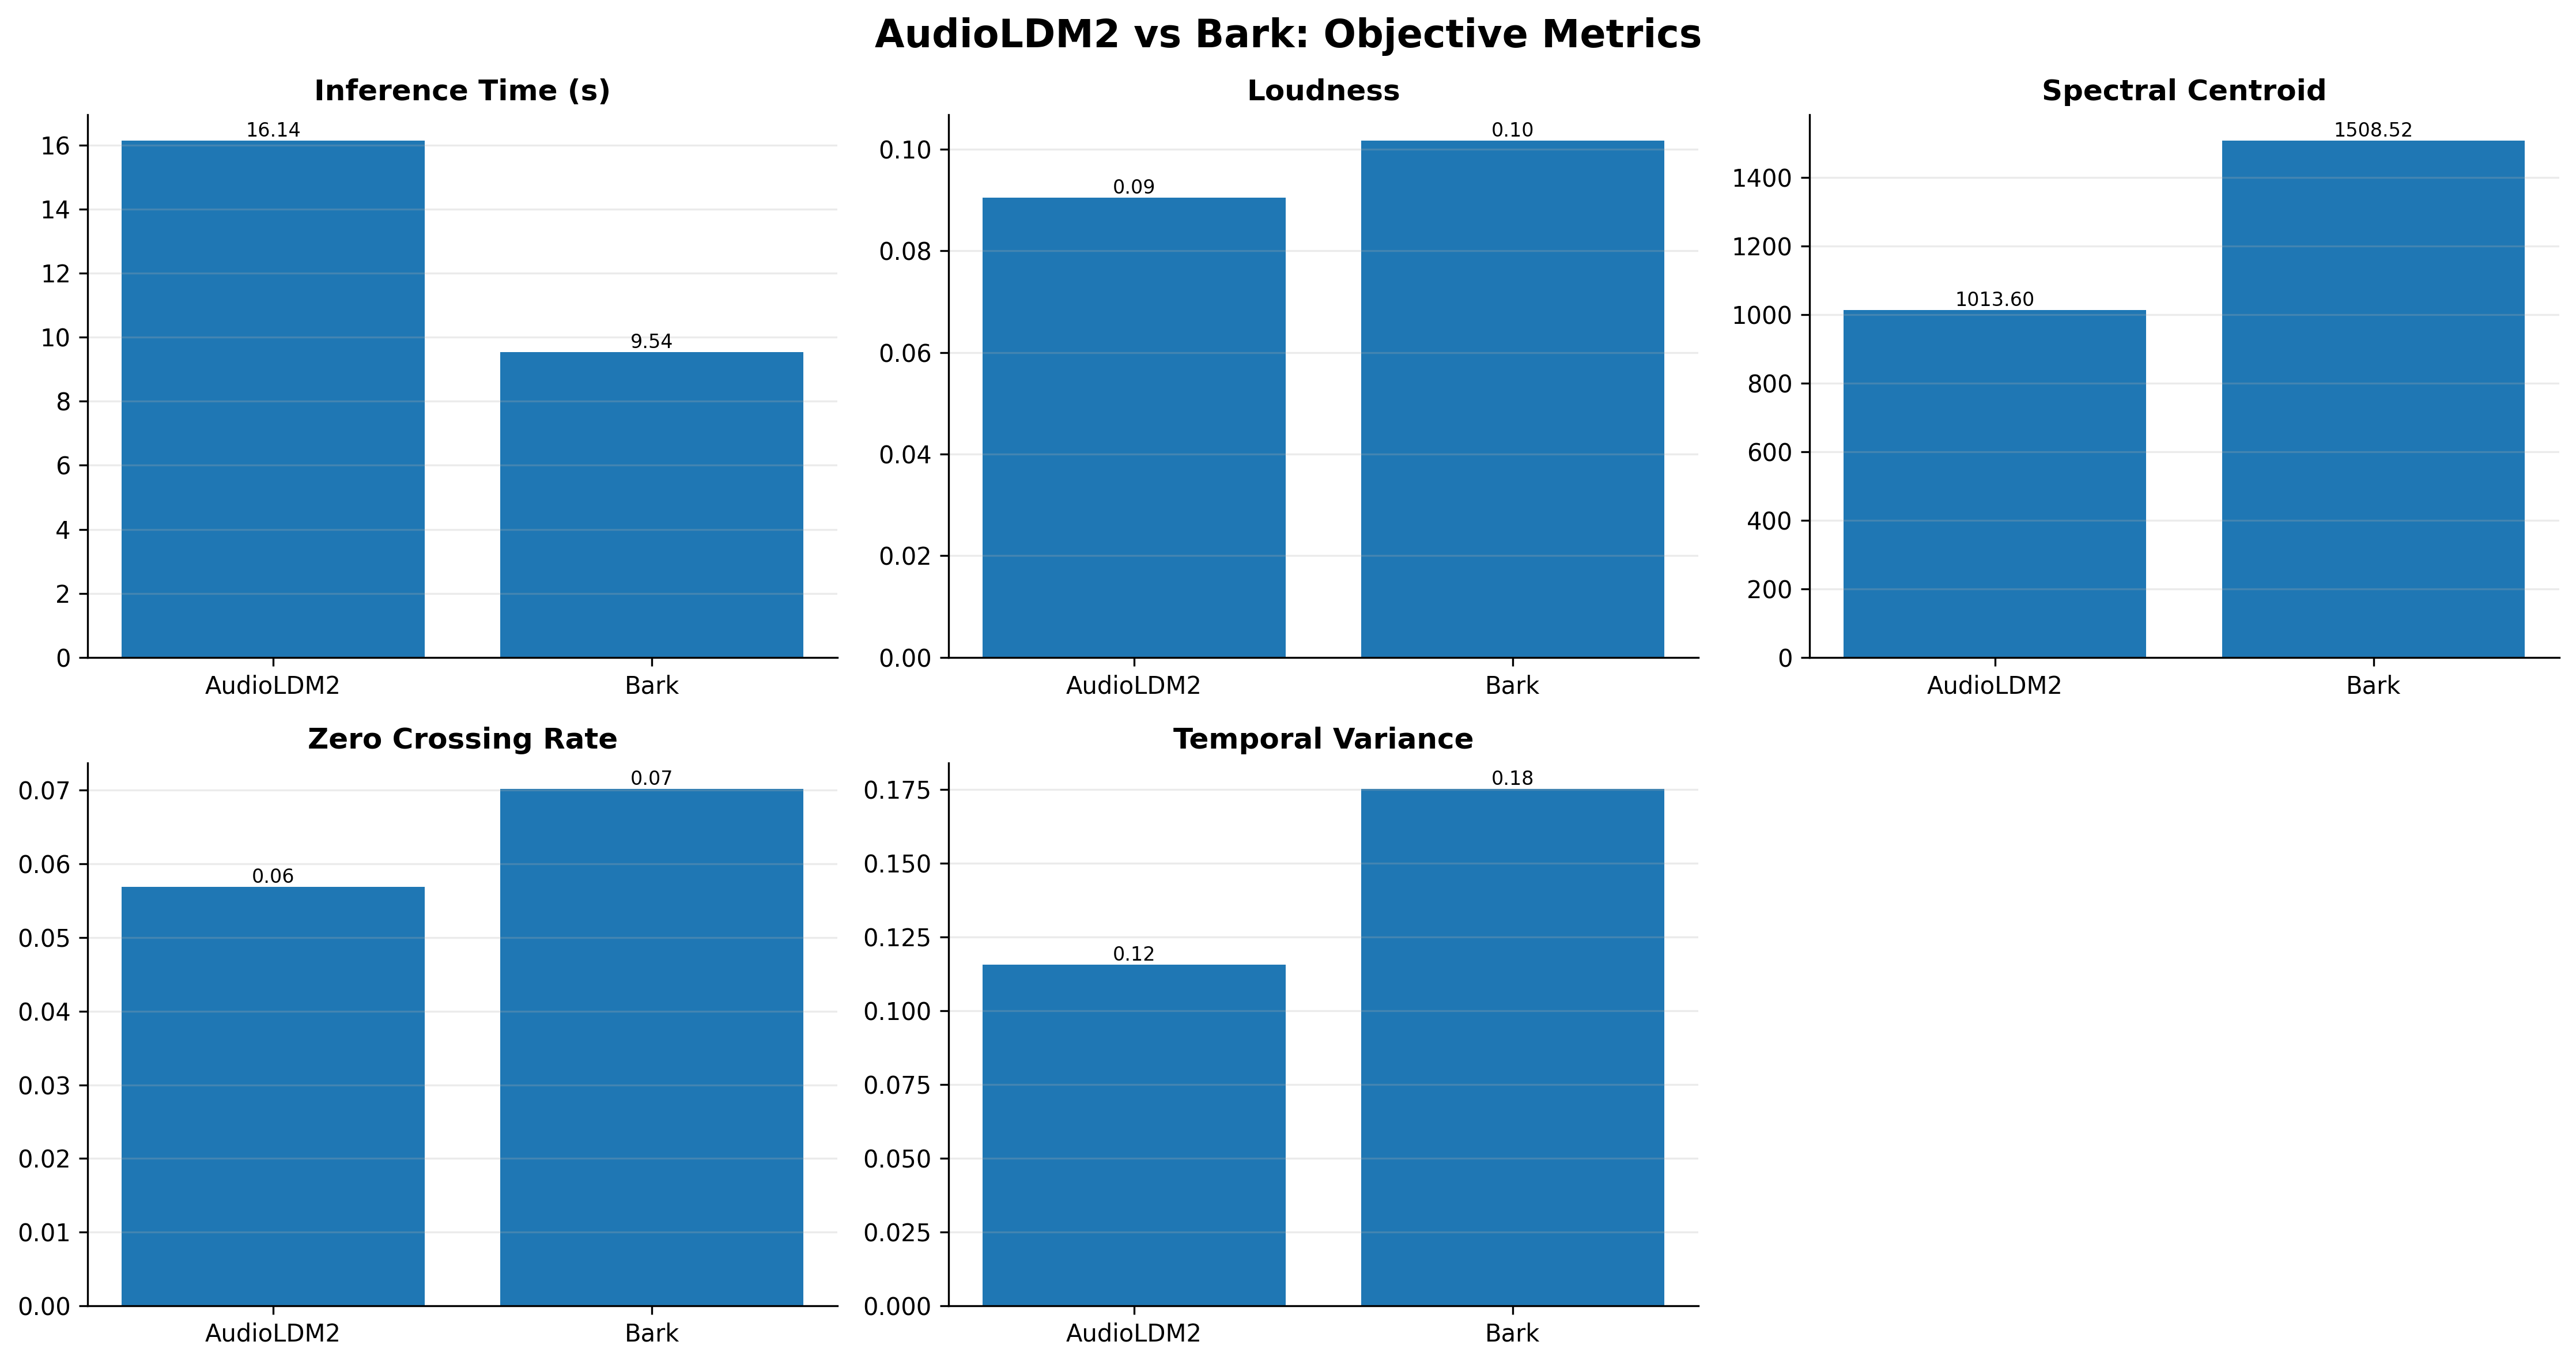

In [14]:
if not summary_df.empty:
    plot_df = summary_df.set_index("Model").drop(columns=["Duration (s)"], errors="ignore")
    
    n_cols = 3
    n_rows = int(np.ceil(len(plot_df.columns) / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = np.ravel(axes)

    for ax, column in zip(axes, plot_df.columns):
        values = plot_df[column]
        bars = ax.bar(values.index, values.values)

        ax.set_title(column, weight="bold")
        ax.grid(axis="y", alpha=0.25)
        ax.spines[["top", "right"]].set_visible(False)

        for bar in bars:
            value = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value,
                f"{value:.2f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    for ax in axes[len(plot_df.columns):]:
        ax.axis("off")

    fig.suptitle("AudioLDM2 vs Bark: Objective Metrics", fontsize=16, weight="bold")
    fig.tight_layout()

    plot_path = OUTPUT_DIR / "comparison_metrics.png"
    fig.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    display(Image(filename=str(plot_path)))

## 10. Save Results

In [15]:
metrics.save_results(OUTPUT_DIR / 'detailed_metrics.json')

print('Saved files:')
for filepath in sorted(OUTPUT_DIR.glob('*')):
    print(filepath)

Saved files:
outputs\AudioLDM2_short_clear.wav
outputs\Bark_short_clear.wav
outputs\comparison_metrics.png
outputs\comparison_results.csv
outputs\detailed_metrics.json
outputs\generated_audio_index.csv
outputs\numba_cache
